# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

## **Code and Explanation**

 Note: ***Most of the code used here is what was showed to us in class. The code was allowed to be used by Dr. Farbin as far as we know what's hapening and can clearly explain the code.***

In [38]:
## base class for managing messages at different levels

class base:
    SILENT = 6
    DEBUG = 1
    INFO = 2
    WARNING = 3
    ERROR = 4
    CRITICAL = 5

    ## Initializing the base class with a default log level 
    def __init__(self, level = 0):
        self.level = level

    ## Log messages only if the level is greater than or equal to the set level
    def message(self, level, *args):
        if level >= self.level:
            print(*args)


In [39]:
## The Card class represents a single card, normal playing card or shuffle card (plastic card)

class Card(base):

    ## Defining suits and values of the cards
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]


    ## Initialize a card with a suit and value
    def __init__(self, suit, value=0):
        base.__init__(self)

        ## Validate if the suit and value of the card is valid
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None

        ## Throwing/Handling Errors
        if self.__suit is None:
            self.message(self.ERROR, "Error, bad suit: ", suit)

        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR, "Error, bad value: ", value)
    
    ## Getter for value
    def value(self):
        return self.__value

    ## Getter for Suit
    def suit(self):
        return self.__suit

    ## Return the numerical value of the cards, (returning numerical values for the corresponding face cards)
    def numerical_value(self):
        if self.__value == "Ace":
            return 1

        elif self.__value in ["Jack", "Queen", "King"]:
            return 10

        else:
            return self.__value

    ## Checking if the current card is shuffle card
    def shuffle_card(self):
        return self.__suit == "ShuffleCard"

    ## String representation of the shuffle card
    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"

        else:
            return str(self.__value) + " of " + self.__suit

    __repr__ = __str__

In [40]:
import random


## The Deck class represents a deck of playing card (single or multiple decks)
class Deck(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    __values = list(range(2, 11)) + ["Jack", "Queen", "King", "Ace"]

    ## Inititalize the deck with a number a decks and a shuffle card (The game is set to play with 6 decks since this is casino standard)
    def __init__(self, n_decks=6):
        base.__init__(self)
        self.__n_decks = n_decks
        self.__cards = list()


        ## Generate the cards for each deck and append a shuffle/plastic card
        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())

        self.__cards.append(Card("ShuffleCard"))

    ## A private function to generate a single deck of cards
    def __make_deck(self):
        deck = list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit, value))

        return deck

    ## shuffling of the deck
    def shuffle(self):
        random.shuffle(self.__cards)


    ## Dealing the card from the deck if deck is empty it will regenerate a deck
    def deal(self):
        if len(self.__cards) > 0:
            return self.__cards.pop()
        else:
            for _ in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()



Testing the Card and Deck classes

In [41]:
my_deck = Deck()
my_deck.shuffle()
[my_deck.deal() for _ in range(10)]

[6 of Clubs,
 Queen of Spades,
 3 of Spades,
 Ace of Hearts,
 6 of Hearts,
 10 of Clubs,
 Ace of Diamonds,
 5 of Diamonds,
 Queen of Spades,
 10 of Spades]

## Calculating Value of Hand

In [42]:
## To calculate the total value of a hand of cards

def calc_hand_value_0(hand):
    return sum(map(lambda card: card.numerical_value(), hand))

In [43]:
## To calculate the total value of a hand of cards considering the scenario if the Ace to be considered as 1 or 11

def calc_hand_value(hand):
    card_values = list(map(lambda card: card.numerical_value(), hand))
    

    ## Count the number of aces
    n_As = len(list(filter(lambda x: x==1, card_values)))

    hand_value= sum(card_values)

    if n_As == 0:
        return hand_value

    Ace_as_one = hand_value
    Ace_as_eleven = hand_value + 10


    ## Checking and returning if value of ace as 11 is less than or equal to 21, oterwise return it as 1
    if Ace_as_eleven <= 21:
        return Ace_as_eleven

    else:
        return Ace_as_one

Testing the above functions

In [44]:
calc_hand_value([Card("Clubs", 10), Card("Clubs", 2), Card("Hearts", "Ace")])

13

In [45]:
calc_hand_value([Card("Clubs", 10), Card("Hearts", "Ace")])

21

## Player Class

In [46]:
## Base class for a player (could be Human or Computer)

class PlayerBase(base):
    def __init__(self, name, n_chips):
        base.__init__(self)
        self.__name = name
        self.__n_chips = n_chips
    
    ## Getter for player's name
    def name(self):
        return self.__name

    ## Getter for player's chips
    def chips(self):
        return self.__n_chips

    ## Add chips to player total
    def pay(self, value= 2):
        self.__n_chips += value

    ## Deduct chips from player's total
    def deduct(self, value= 2):
        if self.__n_chips >= 2:
            self.__n_chips -= value
        else:
            self.__n_chips = 0

    ## This method is implemented in deriuved classes
    def play_hand(self, down_cards, up_cards, seen_cards):
        raise NotImplementedError

       
    ## String representatiuon of the player
    def __str__(self):
        return self.__name + "(" + str(self.__n_chips) + ")"

    __repr__=__str__


## A dealer player class  that inherits from PlayerBase, and has its own play logic (Computer player)
class DealerPlayer(PlayerBase):
    def __init__(self, threshold= 16):
        self.__threshold = threshold
        PlayerBase.__init__(self, "Mr. Dealer", 1000)

    def play_hand(self, down_cards, up_cards, seen_cards):
        hand_value = calc_hand_value([down_cards] + up_cards)
        return hand_value < self.__threshold

## A human player (it will ask user with a promopt to hit or stay)
class ConsolePlayer(PlayerBase):
    def play_hand(self, down_cards, up_cards, seen_cards):
        print("Down Cards: ", down_cards)
        print("Up Cards: ", up_cards)
        print("Seen Cards: ", seen_cards)

        hit_str= input("Hit(Y/N): ")
        return hit_str.upper() == "Y"

## A strategy player who always hits
class Strategy_1_Player(PlayerBase):
    def play_hand(self, down_cards, up_cards, seen_cards):
        return True


In [47]:

## The game class represents the entire game including players, deck and the full gameflow
class Game(base):

    ## Constructor
    def __init__(self, n_decks= 6):
        self.__n_decks = n_decks
        self.__players = list()
        self.__all_players = list()

        self.__shuffle = False          ## Just a flag to check if the deck needs shuffling

    ## Getter for players
    def players(self):
        return self.__players

    ## Get the list of all players
    def all_players(self):
        return self.__all_players

    ## Adding a new player
    def add_player(self, player):
        self.__players.append(player)
        self.__all_players.append(player)

    ## Deal cards and shuffle cards
    def deal_and_check_shuffle(self, deck):
        card = deck.deal()
        if card.shuffle_card():
            shuffle = True
            card = deck.deal()
        return card

    ## Display the status of the game 
    def show_status(self, hands, seen_cards):
        self.message(self.INFO, "-------------------------------------------------------------------")
        self.message(self.INFO, "Hands: ", hands)
        self.message(self.INFO, "Seen Cards: ", seen_cards)
        self.message(self.INFO, "************************************************")
        self.message(self.INFO, "Players: ")
        self.message(self.INFO, "************************************************")
        for i, player in enumerate(self.__all_players):
            self.message(self.INFO, i, ": ", player)
        self.message(self.INFO, "-------------------------------------------------------------------")

    ## Main game loop
    def play_game(self, n_hands):
        # Create Dealer
        self.add_player(DealerPlayer())

        deck = None
        self.__shuffle = False

        for i_hand in range(n_hands):
            ## Filter out players with less than  2 chips
            self.__players = list(filter(lambda player: player.chips() >= 2, self.__players))
            self.message(self.DEBUG, "n player, n all players", len(self.__players), len(self.__all_players))
            self.message(self.DEBUG,"Starting Hand: ", i_hand, " / ", n_hands)

            if deck is None or self.__shuffle:
                self.message(self.DEBUG, "Creating New Deck / Shuffling")
                deck = Deck()
                seen_cards = list()
                self.__shuffle = False

            hands = list()

            ## Down Card Deal
            self.message(self.DEBUG, "Dealing Cards")
            for player_i, player in enumerate(self.__players):
                down_card = self.deal_and_check_shuffle(deck)
                up_cards = list()
                hands.append((down_card, up_cards))
                if player_i < len(self.__players) - 1:
                    seen_cards.append(down_card)

            ## Up Card Deal
            for (down_card, up_cards) in hands:
                up_cards.append(self.deal_and_check_shuffle(deck))
                seen_cards.append(up_cards[-1])

            self.show_status(hands, seen_cards)

            ## Deal Cards
            ## Players are going to play their hands
            for player_i, ((down_card, up_cards), player) in enumerate(zip(hands, self.__players)):
                self.message(self.DEBUG, "Asking Player", player_i, "to Play")
                self.message(self.DEBUG, "Player", player_i, "Hand Total: ", calc_hand_value([down_card]+up_cards))
                hit = True
                this_hand_up_cards = list()
                while(hit):
                    hit = player.play_hand(down_card, up_cards, seen_cards)

                    if hit:
                        self.message(self.DEBUG, "Player", player_i, "Hit")
                        card = self.deal_and_check_shuffle(deck)
                        up_cards.append(card)
                        this_hand_up_cards.append(card)
                        hand_value = calc_hand_value([down_card] + up_cards)
                        self.message(self.DEBUG, "Hand Value: ", hand_value)

                        if hand_value < 21:
                            hit = True
                        else:
                            hit = False
                            if hand_value > 21:
                                self.message(self.DEBUG, "Player ", player_i, " Busted")
                            else:
                                self.message(self.DEBUG, "Player ", player_i, " Got 21")

                    else:
                        self.message(self.DEBUG,"Player ", player_i, "Stay")

                seen_cards.append(down_card)
                seen_cards.extend(this_hand_up_cards)

            hand_values = [calc_hand_value([hand[0]] + hand[1])for hand in hands]

            self.message(self.DEBUG, "Hand Values", hand_value)

            ## Determine who gets paid and who is the winner

            if hand_values[-1] == 21:
                self.message(self.DEBUG, "Dealer got 21")
                for player_i, (hand_value, player) in enumerate(zip(hand_values[:-1], self.__players[:-1])):
                    if hand_value == 21:
                        self.message(self.DEBUG, "Player ", player_i, " Got 21. Paying 3 chips")
                        player.pay(3)

                    elif hand_value > 21:
                        self.message(self.DEBUG, "Player ", player_i, " Busted. Deducting 2 chips")
                        player.deduct(2)
                    elif hand_value > hand_values[-1]:
                        self.message(self.DEBUG, "Player ", player_i, " hand was ", hand_value, " versus dealer hand", hand_values[-1], " Paying 2 chips")
                        player.pay(2)

                    else:
                        self.message(self.DEBUG, "Player", player_i, " hand was ", hand_value, " versus Dealer hand", hand_values[-1], " Deducting 2 chips")
                        player.deduct(2)
                        

        

### **Main Gameplay using Human Player**

In [48]:
my_game = Game()
my_game.level = Game.DEBUG

my_game.add_player(Strategy_1_Player("Dummy player", 100))
my_game.add_player(ConsolePlayer("Me", 100))

my_game.play_game(2)

n player, n all players 3 3
Starting Hand:  0  /  2
Creating New Deck / Shuffling
Dealing Cards
-------------------------------------------------------------------
Hands:  [(Ace of Spades, [Jack of Spades]), (King of Spades, [10 of Spades]), (Queen of Spades, [9 of Spades])]
Seen Cards:  [Ace of Spades, King of Spades, Jack of Spades, 10 of Spades, 9 of Spades]
************************************************
Players: 
************************************************
0 :  Dummy player(100)
1 :  Me(100)
2 :  Mr. Dealer(1000)
-------------------------------------------------------------------
Asking Player 0 to Play
Player 0 Hand Total:  21
Player 0 Hit
Hand Value:  19
Player 0 Hit
Hand Value:  26
Player  0  Busted
Asking Player 1 to Play
Player 1 Hand Total:  20
Down Cards:  King of Spades
Up Cards:  [10 of Spades]
Seen Cards:  [Ace of Spades, King of Spades, Jack of Spades, 10 of Spades, 9 of Spades, Ace of Spades, 8 of Spades, 7 of Spades]
Player 1 Hit
Hand Value:  26
Player  1  Buste

## **Automatic Game**: This game involves Ai players (computer players). 
We have this function so that the game can be played on it's own, we can observe the randomness of the game.

In [52]:
class Strategy_1_Player(PlayerBase):
    def play_hand(self, down_cards, up_cards, seen_cards):
        return True
class Strategy_2_Player(PlayerBase):
    def play_hand(self, down_cards, up_cards, seen_cards):
        return True

class DealerLikePlayer(PlayerBase):
    def __init__(self, name, chips, threshold= 16):
        self.__threshold = threshold
        PlayerBase.__init__(self, name, chips)

    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        return hand_value < self.__threshold

        

In [53]:
my_game = Game()
my_game.level = Game.SILENT

my_game.add_player(Strategy_1_Player("Dummy Player", 100))
my_game.add_player(DealerLikePlayer("Stays on 13", 100, 13))
my_game.add_player(DealerLikePlayer("Stays on 14", 100, 14))
my_game.add_player(DealerLikePlayer("Stays on 15", 100, 15))
my_game.add_player(DealerLikePlayer("Stays on 16", 100, 16))
my_game.add_player(DealerLikePlayer("Stays on 17", 100, 17))
my_game.add_player(DealerLikePlayer("Stays on 18", 100, 18))
my_game.add_player(DealerLikePlayer("Stays on 19", 100, 19))
my_game.add_player(DealerLikePlayer("Stays on 20", 100, 20))

my_game.play_game(10)

In [54]:
[player.chips() for player in my_game.players()]

[100, 100, 100, 100, 100, 100, 100, 100, 100, 1000]

In [55]:
def play_a_round(n_hands= 50):
    my_game = Game()
    my_game.level=Game.ERROR

    my_game.add_player(Strategy_1_Player("Dummy Player", 100))
    my_game.add_player(DealerLikePlayer("Stays on 13", 100, 13))
    my_game.add_player(DealerLikePlayer("Stays on 14", 100, 14))
    my_game.add_player(DealerLikePlayer("Stays on 15", 100, 15))
    my_game.add_player(DealerLikePlayer("Stays on 16", 100, 16))
    my_game.add_player(DealerLikePlayer("Stays on 17", 100, 17))
    my_game.add_player(DealerLikePlayer("Stays on 18", 100, 18))
    my_game.add_player(DealerLikePlayer("Stays on 19", 100, 19))
    my_game.add_player(DealerLikePlayer("Stays on 20", 100, 20))

    my_game.play_game(n_hands)

    return [player.chips() for player in my_game.players()]

In [56]:
results = play_a_round(100)

In [57]:
results

[95, 80, 85, 85, 80, 80, 85, 100, 90, 1000]

In [58]:
def play_many_rounds(n_rounds= 100, n_hands= 50):
    results = list()

    for i_round in range(n_rounds):
        results.append(play_a_round(n_hands))

    return results

In [59]:
results= play_many_rounds(1000)

In [62]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Graph:
This graph basically showcase the winning of each player

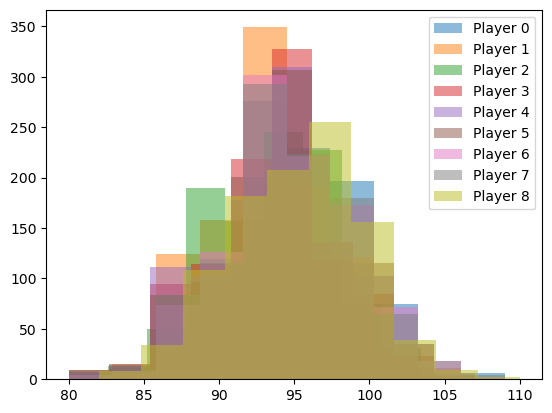

In [69]:
res  = np.array(results)
res = res [:, :-1]

for i in range(res.shape[1]):
    plt.hist(res[:,i], label= "Player " + str(i), alpha= 0.5)
plt.legend()
plt.show()

In [70]:
m = np.mean(res,axis= 0)

In [71]:
s = np.std(res, axis= 0)

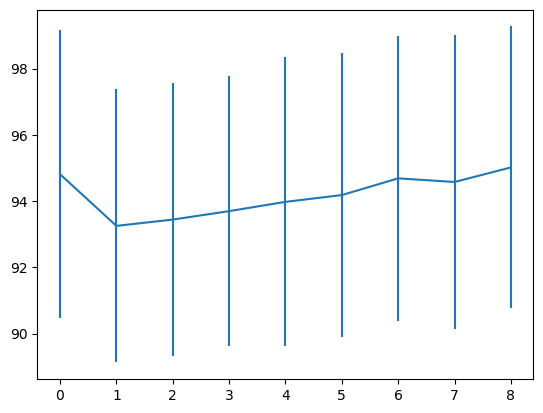

In [72]:
plt.errorbar(range(len(m)), m, s)
plt.show()